In [2]:
version = "v2.2.3"
revision_date = "20240210"

In [3]:
# update this string!
student_name = "Daniel"

In [4]:
print(f"Notebook version {version}")

if student_name == "First Last":
    raise Exception("Please update your name in the 'student_name' variable at the top of this notebook.")

print(f"Student name: {student_name}")

Notebook version v2.2.3
Student name: Daniel


# **Course Minimum Score Notice**
- Student must achieve a _**Passing**_ score on **ALL** course assignments and quizzes to receive credit for this course.  
- What defines a _**Passing**_ score?
  - Students must attain a **Raw Score** of not less than 80.0% on **All** assignments and quizzes.  
  - The **Raw Score** is that score achieved prior to the _final_ application of incurred late penalties. 

<a id='toc'></a>
# Table of Contents
- **[Assignment 1 Part 2 Description](#Topic0)**
  - [Breast Cancer Wisconsin dataset import](#bcwdi)
  - [Task 0 - Warm-up](#t0)
  - [Task 1 - Data Transformation](#t1)
  - [Task 2 - Class Distribution](#t2)
  - [Task 3 - Data Preparation](#t3)
  - [Task 4 - Train-Test Split](#t4)
  - [Task 5 - KNN Classifier Construction](#t5)
  - [Task 6 - KNN Prediction on Mean Vector](#t6)
  - [Task 7 - KNN Prediction on the Test Set](#t7)
  - [Task 8 - Evaluation on the Test Set](#t8)
    - [Accuracy plot code](#apc)
    - [Accuracy plot \#1](#accplot1)
  - [Task 9 - Model Hyper-parameters](#t9)
    - [Accuracy plot \#2](#accplot2)  
  - [Task 10 - Weighted KNN](#t10)
  - [Task 11 - Model Hyper-parameter Tuning](#t11)
  - [Task 12 - Overfitting](#t12)
  - [Task 13 - One-Hot Encoding](#t13)

In [5]:
# Either of the following is no longer
# necessary for matplotlib in notebooks.
# The import statement has you covered!

# %matplotlib notebook
# %matplotlib inline

<a id='Topic0'></a>
# Assignment 1 Part 2: Introduction to Supervised Machine Learning
In this assignment you will be using the [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)) dataset to create a classifier that can help diagnose patients. We chose this data not only because it provides a good basis for a kNN classification problem, but also because it illustrates one of the built-in datasets that comes with [scikit-learn](https://scikit-learn.org/stable/user_guide.html).  

<a href='#toc'>TOC</a>

In [6]:
# Suppress all warnings only when absolutely necessary
# Warnings are in place for a reason!
import warnings

# warnings.filterwarnings('ignore')
# warnings.simplefilter('ignore')

In [7]:
from functools import lru_cache
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.utils import Bunch
from mads.lib.path import assets

up, down = True, False

In [8]:
np.set_printoptions(precision=3)

## Additional imports can be inlcuded here

<a id='bcwdi'></a>
### [Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer) dataset import.

Note that the object returned by `load_breast_cancer()` is a scikit-learn [Bunch](https://scikit-learn.org/stable/modules/generated/sklearn.utils.Bunch.html) object which is similar to a Python dictionary.  

To view the `bunch` attributes, use the `.keys()` method of the cancer object. Feel free to explore this object yourself. 

<a href='#toc'>TOC</a>

In [9]:
# Load the dataset from scikit-learn.

cancer = load_breast_cancer()

In [10]:
# To see a description of the dataset, uncomment the following print statement.
# Remember to comment the following function calls before submitting the notebook.

print(cancer.keys(), "\n")
# print(cancer.DESCR)
type(cancer)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) 



sklearn.utils._bunch.Bunch

In [11]:
data= np.column_stack((cancer.data, cancer.target))
data.shape

(569, 31)

<a id='t0'></a>
### Task 0 - Warm-up (5 points).

Understanding how many features you're dealing with and what each feature represents is an essential first step in machine learning.  So, how many features are there in this dataset?  

Complete the function below based on the following:
 - The function should accept one positional object of type Bunch
 - Determine the number of features of the contained dataset
 - Return the feature count as an integer.  

<a href='#toc'>TOC</a> 

In [12]:
# hidden autograder codeblock
task_id = "0"

In [13]:
def feature_count(cancer):
    result = None

    # YOUR CODE HERE
    result= len(cancer.feature_names)
    #raise NotImplementedError()

    return result

In [14]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# feature_count(cancer)
features=feature_count(cancer)
features

30

In [15]:
## AutoGrader tests cell
print(f"Task {task_id} - AG tests")

stu_ans = feature_count(cancer)

print(f"Task {task_id} - your answer: {stu_ans}")

assert isinstance(stu_ans, int), f"Task {task_id}: Your return value should be an integer."

# Hidden Tests Below

del stu_ans

Task 0 - AG tests
Task 0 - your answer: 30


<a id='t1'></a>
### Task 1 - Data Transformation (10 points).

In a lot of cases, raw data may not come in a form that's amenable to further manipulation or interpretation. Therefore, we may need to transform the raw data so that it better fits our purposes. In this assignment, we will store the data in a more human-friendly tabular format as a [pandas.DataFrame](https://pandas.pydata.org/pandas-docs/version/1.5/reference/frame.html).

Complete the function below to return a `pd.DataFrame` of the shape `(569, 31)` with the following columns: 
```
['mean radius', 'mean texture', 'mean perimeter', 'mean area',
'mean smoothness', 'mean compactness', 'mean concavity',
'mean concave points', 'mean symmetry', 'mean fractal dimension',
'radius error', 'texture error', 'perimeter error', 'area error',
'smoothness error', 'compactness error', 'concavity error',
'concave points error', 'symmetry error', 'fractal dimension error',
'worst radius', 'worst texture', 'worst perimeter', 'worst area',
'worst smoothness', 'worst compactness', 'worst concavity',
'worst concave points', 'worst symmetry', 'worst fractal dimension',
'target']
```  
Complete the function below based on the following:
 - The function should accept one positional object (cancer) of type Bunch
 - Determine the number of features of the contained dataset
 - Return a pandas.DataFrame of the shape `(569, 31)`.  
 
**Note that this function should be used by tasks beyond just task 1!**  

<a href='#toc'>TOC</a>

In [16]:
# hidden autograder codeblock
task_id = "1"

In [17]:
def make_cancer_dataframe(cancer: Bunch) -> pd.DataFrame:
    cancer_df = None

    # YOUR CODE HERE
    columns=['mean radius', 'mean texture', 'mean perimeter', 'mean area','mean smoothness', 'mean compactness', 'mean concavity',
             'mean concave points', 'mean symmetry', 'mean fractal dimension','radius error', 'texture error', 'perimeter error', 
             'area error','smoothness error', 'compactness error', 'concavity error','concave points error', 'symmetry error', 
             'fractal dimension error','worst radius', 'worst texture', 'worst perimeter', 'worst area','worst smoothness', 'worst compactness', 
             'worst concavity','worst concave points', 'worst symmetry', 'worst fractal dimension','target']
    stacked_data= np.column_stack((cancer.data, cancer.target))
    cancer_df=pd.DataFrame(stacked_data, columns =columns )
    #raise NotImplementedError()

    return cancer_df

In [18]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# make_cancer_dataframe(cancer).head()
make_cancer_dataframe(cancer).head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [19]:
# Autograder tests cell
print(f"Task {task_id} - AG tests")
stu_ans = make_cancer_dataframe(cancer)

# print(f"Task {task_id} - your answer:\n{stu_ans.head()}")

assert (
    type(stu_ans) == pd.core.frame.DataFrame
), f"Task {task_id}: Your function did not return a Pandas DataFrame."

assert stu_ans.shape == (
    569,
    31,
), f"Task {task_id}: The shape of your dataframe isn't correct. "

assert list(stu_ans.columns) == [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "smoothness error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension",
    "target",
], "Task 1: Please check the column names of your dataframe."

# Some hidden tests
del stu_ans

Task 1 - AG tests


<a id='t2'></a>
### Task 2 - Class Distribution (5 points).

It's often a good idea to get some descriptive statistics, such as mean and variance of certain features, on the data at hand to understand the big picture. 

In particular, it's always a good idea to ask: what is the class distribution? That is, how many instances belong to the *malignant* class (encoded as 0) and the *benign* class (encoded as 1), respectively? Complete the function below to return the class distribution as a [pandas.Series](https://pandas.pydata.org/pandas-docs/version/1.5/reference/series.html) of length 2 whose index is  `['malignant', 'benign']`  

<a href='#toc'>TOC</a>

In [20]:
# hidden autograder codeblock
task_id = "2"

In [21]:
def get_target_distro():
    distro = None

    # YOUR CODE HERE
    target=pd.Series(cancer.target)
    distro= target.value_counts().sort_index()
    distro.index=['malignant', 'benign']
    #raise NotImplementedError()

    return distro

In [22]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# get_target_distro()
get_target_distro()

malignant    212
benign       357
Name: count, dtype: int64

In [23]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = get_target_distro()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, pd.Series), f"Task {task_id}: Your result should be a pd.Series."

# Some hidden tests

del stu_ans

Task 2 - AG tests
Task 2 - your answer:
malignant    212
benign       357
Name: count, dtype: int64


<a id='t3'></a>
### Task 3 - Data Preparation (5 points).

Training a classifier is a *supervised* machine learning problem, in which each instance $x_i$ has a corresponding class label $y_i$. All the instances $x_i$'s are collected into a matrix $X$ (with one instance per row of $X$), and all the corresponding labels are put into a column vector $y$. 

Now let's prepare the data for use with [scikit-learn](https://scikit-learn.org/1.2/user_guide.html). Complete the function below to split our DataFrame into `X` (the data) and `y` (the labels), and to return them as a `tuple`, where
* `X` is a `pd.DataFrame` of the shape `(569, 30)`
* `y` is a `pd.Series` of the shape `(569,)`.  

<a href='#toc'>TOC</a>

In [24]:
# hidden autograder codeblock
task_id = "3"

In [25]:
def prepare_X_y():
    X, y = None, None

    # YOUR CODE HERE
    columns=['mean radius', 'mean texture', 'mean perimeter', 'mean area','mean smoothness', 'mean compactness', 'mean concavity',
             'mean concave points', 'mean symmetry', 'mean fractal dimension','radius error', 'texture error', 'perimeter error', 
             'area error','smoothness error', 'compactness error', 'concavity error','concave points error', 'symmetry error', 
             'fractal dimension error','worst radius', 'worst texture', 'worst perimeter', 'worst area','worst smoothness', 'worst compactness', 
             'worst concavity','worst concave points', 'worst symmetry', 'worst fractal dimension','target']
    stacked_data= np.column_stack((cancer.data, cancer.target))
    cancer_df=pd.DataFrame(stacked_data, columns =columns )
    X, y = cancer_df.iloc[:, :30], cancer_df['target']
    #raise NotImplementedError()

    return X, y

In [26]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# prepare_X_y()
prepare_X_y()

(     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  mean conca

In [27]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = prepare_X_y()

# print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, tuple), f"Task {task_id}: You should return a tuple!"

assert isinstance(stu_ans[0], pd.DataFrame), f"Task {task_id}: X should be a pandas.DataFrame. "
assert stu_ans[0].shape == (569, 30), f"Task {task_id}: The shape of X is incorrect."

assert isinstance(stu_ans[1], pd.Series), f"Task {task_id}: y should be a pandas.Series. "
assert stu_ans[1].shape == (569,), f"Task {task_id}: The shape of y is incorrect."

# Some hidden tests

del stu_ans

Task 3 - AG tests


<a id='t4'></a>
### Task 4 - Train-Test Split (10 points).

For a typical machine learning problem, we'd need two separate datasets, one for training a model and the other for evaluating the trained model for its generalisability to unseen data. `scikit-learn` provides a very handy [train_test_split()](https://scikit-learn.org/1.2/modules/generated/sklearn.model_selection.train_test_split.html) function for this purpose.  

Now, complete the function below that uses the `train_test_split` function to split `X` and `y` into training and testing sets. The functions accepts three arguments, X, y, and random_state. X may be a (m by n) pandas DataFrame or numpy array. y may be an pandas Series or an (m, ) numpy array. The third argument is an integer used by the random_state parameter.  

Your function should return a `tuple` `(X_train, X_test, y_train, and y_test)` where, for the breast cancer dataset, 
* `X_train` is of the shape `(426, 30)`
* `X_test` is of the shape `(143, 30)`
* `y_train` is of the shape `(426,)`
* `y_test` is of the shape `(143,)`

**IMPORTANT: Set the random number generator state to the number 42 by specifying `random_state=42` to ensure a deterministic result that matches that of the autograder.**   Why the number 42?  Please see: [Douglas Adams and the cult of 42](https://www.theguardian.com/books/2011/feb/03/douglas-adams-42-hitchhiker)

(In later work, we'll actually use a slightly more sophisticated splitting scheme that uses training, validation, and test sets, but we'll cover this later as part of a technique called cross-validation.)  

<a href='#toc'>TOC</a>

In [28]:
# hidden autograder codeblock
task_id = "4"

In [29]:
from sklearn.model_selection import train_test_split


def get_train_test(X: (pd.DataFrame or np.ndarray), y: (pd.Series or np.ndarray), random_state: int) -> tuple:
    X_train, X_test, y_train, y_test = (None,) * 4

    # YOUR CODE HERE
   
    X_train, X_test, y_train, y_test=train_test_split(X, y,random_state=random_state)
    #raise NotImplementedError()

    return X_train, X_test, y_train, y_test

In [30]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

random_state = 42

# X, y = prepare_X_y()
# X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)

# Notice how we unpack the prepare_X_y() return values directly in the call to get_train_test()!
X_train, X_test, y_train, y_test = get_train_test(*prepare_X_y(), random_state)

In [31]:
# Autograder tests

stu_ans = get_train_test(*prepare_X_y(), 42)

assert stu_ans[0].shape == (
    426,
    30,
), f"Task {task_id}: The shape of X_train is incorrect."
assert stu_ans[2].shape == (426,), f"Task {task_id}: The shape of y_train is incorrect."

assert stu_ans[1].shape == (
    143,
    30,
), f"Task {task_id}: The shape of X_test is incorrect."
assert stu_ans[3].shape == (143,), f"Task {task_id}: The shape of y_test is incorrect."

# Some hidden tests

del stu_ans

<a id='t5'></a>
### Task 5 - kNN Classifier Construction (5 points).

Use [KNeighborsClassifier](https://scikit-learn.org/1.2/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) from `scikit-learn` to fit a $k$-Nearest Neighbours ($k$NN) classifier with `X_train` and `y_train` where `k=1`. Your function should return the trained classifier itself, which is a `sklearn.neighbors.KNeighborsClassifier` object.  

<a href='#toc'>TOC</a>

In [32]:
# hidden autograder codeblock
task_id = "5"

In [33]:
from sklearn.neighbors import KNeighborsClassifier


def k_nearest_neighbors(random_state):
    knn = None

    # YOUR CODE HERE
    X, y= prepare_X_y()
    classifier= KNeighborsClassifier(n_neighbors=1)
    knn= classifier.fit(X_train, y_train)
    #raise NotImplementedError()

    return knn

In [34]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# k_nearest_neighbors(42)
k_nearest_neighbors(42)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
# Autograder tests
print(f"Task {task_id} - AG tests")
random_state = 42
stu_ans = k_nearest_neighbors(random_state)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, KNeighborsClassifier
), f"Task {task_id}: The object returned by your function is not of the correct type."

# Some hidden tests

del stu_ans

Task 5 - AG tests
Task 5 - your answer:
KNeighborsClassifier(n_neighbors=1)


<a id='t6'></a>
### Task 6 - KNN Prediction on Mean Vector (10 points).

It's often useful and interesting to know what class a "typical" or "average" data point belongs to. Use your kNN classifier from the last task to predict the class label for the *mean vector* of the training data. Your function should return the predicted class label as a singleton numpy array --- either `array([ 0.])` or `array([ 1.])`. 

If you encounter errors complaining that the shape of your data isn't correct, carefully check the [KNN documentation](https://scikit-learn.org/1.2/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.predict) of the `predict` function. Another useful hint is to consider what kind of object `X_train` is. How do you make sure it is in the correct shape?  

<a href='#toc'>TOC</a>

In [36]:
# hidden autograder codeblock
task_id = "6"

In [37]:
def knn_predict_on_mean(random_state):
    pred = None

    # YOUR CODE HERE

    # calling X, y, and train_test_splits
    X, y = prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    knn=k_nearest_neighbors(1)
    
    fitt=knn.fit(X_train,y_train)
    mean_vector= X_train.mean( axis=0).values.reshape(1,-1)
    pred=knn.predict(mean_vector)
    #raise NotImplementedError()

    return pred

In [38]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_predict_on_mean(42)
knn_predict_on_mean(42)

/usr/local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1.])

In [39]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_predict_on_mean(42)

print(f"Task {task_id} - your answer: {stu_ans}")

assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: The function should return an object of type numpy.ndarray."

# Some hidden tests

del stu_ans

Task 6 - AG tests
Task 6 - your answer: [1.]


/usr/local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


<a id='t7'></a>
### Task 7 - KNN Prediction on the Test Set (5 points).

Now, use your KNN classifier to predict class labels for the test set `X_test`. Your function should return a  [numpy.ndarray](https://numpy.org/doc/1.24/reference/generated/numpy.ndarray.html) of the shape `(143,)` whose values are either [0, 1] or [0.0, 1.0] i.e., the results are binary.  

<a href='#toc'>TOC</a>

In [40]:
# hidden autograder codeblock
task_id = "7"

In [41]:
def knn_predict_on_test(random_state):
    preds = None

    # YOUR CODE HERE
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    knn=k_nearest_neighbors(1)
    
    fits= knn.fit(X_train, y_train)
    scores=knn.score(X_test,y_test)
    preds=knn.predict(X_test)
    #raise NotImplementedError()

    return preds

In [42]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_predict_on_test(42)
preds= knn_predict_on_test(42)



In [43]:
print(np.array(y_test))

[1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 0.
 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1.]


In [44]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_predict_on_test(42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, np.ndarray), f"Task {task_id}: Your function should return a numpy.ndarray. "


del stu_ans

Task 7 - AG tests
Task 7 - your answer:
[1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0.
 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1.]


<a id='t8'></a>
### Task 8. Evaluation on the Test Set (5 points).

Once you have the predictions on the test set, you may compare them with the ground-truth labels to gauge how well your model performs when given unseen data. 

Complete the function below to compute the score (mean accuracy) of your KNN classifier using the test set `X_test` and the test labels `y_test`. The function should return a `float` between 0 and 1.  

<a href='#toc'>TOC</a>

In [45]:
# hidden autograder codeblock
task_id = "8"

In [46]:
def knn_score_prediction(random_state):
    score = None

    # YOUR CODE HERE
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    knn=k_nearest_neighbors(1)

    knn.fit(X_train, y_train)
    score= knn.score(X_test, y_test)
    
    #raise NotImplementedError()

    return score

In [47]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_score_prediction(random_state=42)
knn_score_prediction(42)

0.9300699300699301

In [48]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_score_prediction(42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, float) or isinstance(stu_ans, np.floating), (
    f"Task {task_id}: Your function should return a Python float or numpy float, but got {type(stu_ans)}."
) 

del stu_ans

Task 8 - AG tests
Task 8 - your answer:
0.9300699300699301


<a id='apc'></a>
### Accuracy plot code block.
<a href='#toc'>TOC</a>

In [49]:
def accuracy_plot(knn, random_state):
    X_train, X_test, y_train, y_test = get_train_test(*prepare_X_y(), random_state)

    # Find the training and testing accuracies by target value (i.e. malignant, benign)
    mal_train_X = X_train[y_train == 0]
    mal_train_y = y_train[y_train == 0]
    ben_train_X = X_train[y_train == 1]
    ben_train_y = y_train[y_train == 1]

    mal_test_X = X_test[y_test == 0]
    mal_test_y = y_test[y_test == 0]
    ben_test_X = X_test[y_test == 1]
    ben_test_y = y_test[y_test == 1]

    scores = [
        knn.score(mal_train_X, mal_train_y),
        knn.score(ben_train_X, ben_train_y),
        knn.score(mal_test_X, mal_test_y),
        knn.score(ben_test_X, ben_test_y),
    ]

    plt.figure(figsize=(8, 6))

    # Plot the scores as a bar chart
    bars = plt.bar(np.arange(4), scores, color=["#4c72b0", "#4c72b0", "#55a868", "#55a868"])

    # directly label the score onto the bars
    for bar in bars:
        height = bar.get_height()
        plt.gca().text(
            bar.get_x() + bar.get_width() / 2,
            height * 0.90,
            "{0:.{1}f}".format(height, 2),
            ha="center",
            color="w",
            fontsize=11,
        )

    # remove all the ticks (both axes), and tick labels on the Y axis
    plt.tick_params(
        top="off",
        bottom="off",
        left="off",
        right="off",
        labelleft="off",
        labelbottom="on",
    )

    # remove the frame of the chart
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.xticks(
        [0, 1, 2, 3],
        ["Malignant\nTraining", "Benign\nTraining", "Malignant\nTest", "Benign\nTest"],
        alpha=0.8,
    )

    plt.title("Training and Test Accuracies for Malignant and Benign Cells", alpha=0.8)

<a id='accplot1'></a>
### Accuracy plot #1 (optional)

Note: The following plots will help you to evaluate the model with showing the prediction accuracy in training and testing set.  You can pass in any trained classifier as the argument.  

Try using the plotting function below to visualize the different predicition scores between training and test sets, as well as malignant and benign cells.

<a href='#toc'>TOC</a>

In [50]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

#accuracy_plot(k_nearest_neighbors(random_state=42), random_state=42)

<a id='t9'></a>
### Task 9 - Model Hyper-parameters (5 points).

It's common to experiment with different configurations of a model, also known as "hyper-parameters" which are typically specified in advance of starting the step of estimating the learnable "parameters" of a specific model configuration in order to achieve better performance. The critical hyper-parameter of a KNN model is $k$, the number of neighbors to examine. 

Change $k$ to 15 and fit the model with training data. Complete the function below to return the trained model, which is a [sklearn.neighbors.KNeighborsClassifier](https://scikit-learn.org/1.2/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) object. Compare this with the results above for $k$ = 1.  

<a href='#toc'>TOC</a>

In [51]:
# hidden autograder codeblock
task_id = "9"

In [52]:
def knn_hyperparameter_change(random_state):
    knn = None

    # YOUR CODE HERE
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    parameter= KNeighborsClassifier(n_neighbors=15)
    knn=parameter.fit(X_train, y_train)
    #raise NotImplementedError()

    return knn

In [53]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_hyperparameter_change(random_state=42)
knn_hyperparameter_change(random_state=42)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_hyperparameter_change(random_state=42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, KNeighborsClassifier
), f"Task {task_id}: Your function did not return an object of the correct type."

# Some hidden tests
del stu_ans

Task 9 - AG tests
Task 9 - your answer:
KNeighborsClassifier(n_neighbors=15)


<a id='accplot2'></a>
### Accuracy plot #2 (optional)

Note: The following plots will help you to evaluate the model with showing the prediction accuracy in training and testing set.  You can pass in any trained classifier as the argument.  

Try using the plotting function below to visualize the different predicition scores between training and test sets, as well as malignant and benign cells.

<a href='#toc'>TOC</a>

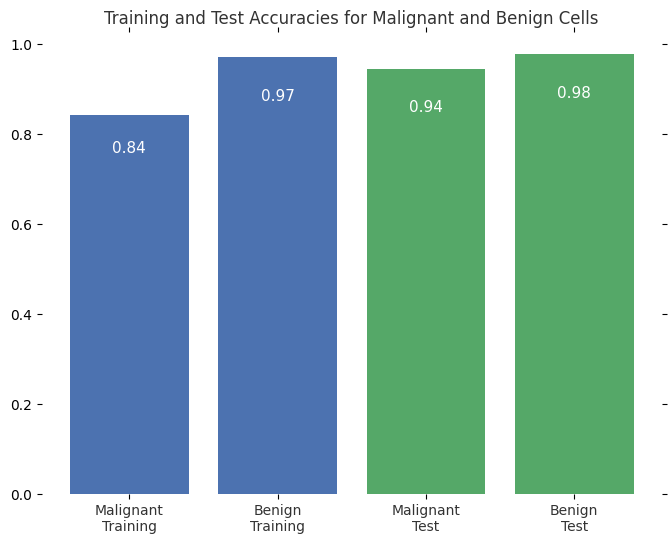

In [55]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# accuracy_plot(knn_hyperparameter_change(42), random_state=42)
accuracy_plot(knn_hyperparameter_change(42), random_state=42)

<a id='t10'></a>
### Task 10 - Weighted KNN (5 points).

Keeping $k = 15$, now change the KNN method to use a *weighted* distance measure: this means closer neighbors of a query point will have more influence on the prediction than neighbors which are a greater distance away. (Normally, the default KNN classifier uses a uniform weighting, i.e. it ignores how far a neighbor is and just sees that it exists.)

Your function below should return a trained KNN classifier of the type `sklearn.neighbors.KNeighborsClassifier`. (You may find it helpful to plot and compare the results with the unweighted distance measure, using the provided plotting function.)  

<a href='#toc'>TOC</a>

In [56]:
# hidden autograder codeblock
task_id = "10"

In [57]:
def knn_weighted_distance(random_state):
    knn = None

    # YOUR CODE HERE
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    untrained=KNeighborsClassifier(n_neighbors=15, weights='distance')
    knn=untrained.fit(X_train, y_train)
    #raise NotImplementedError()

    return knn

In [58]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_weighted_distance(42)
knn_weighted_distance(42)

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [59]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_weighted_distance(42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, KNeighborsClassifier
), f"Task {task_id}: Your function did not return an object of the correct type."

# Some hidden tests
del stu_ans

Task 10 - AG tests
Task 10 - your answer:
KNeighborsClassifier(n_neighbors=15, weights='distance')


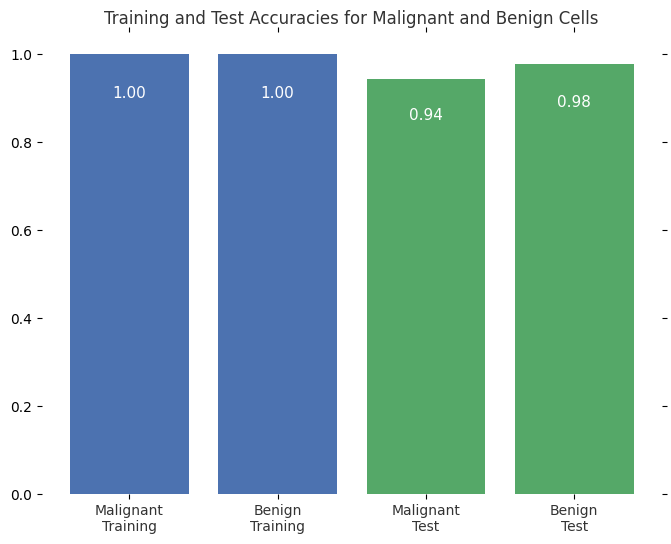

In [60]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# accuracy_plot(knn_weighted_distance(42), random_state=42)
accuracy_plot(knn_weighted_distance(42), random_state=42)

<a id='t11'></a>
### Task 11: Model Hyper-parameter Tuning (10 points).

It is important to improve algorithm design through automatically changing the parameter based on data-driven evidence, because it is more effective than just 'trying out' different parameters by hand.

Perform a simple parameter sweep for all **odd** values of $k$ from 1 to 19 inclusive (a simple loops works well here), and return the optimal value of $k$ that leads to the highest overall *test set accuracy* on this train/test split.  Accuracy is computed using the **score** method. Your code should return an integer between 1 and 19. In case of a tie, return the smallest best $k$.  

<a href='#toc'>TOC</a>

In [61]:
# hidden autograder codeblock
task_id = "11"

In [62]:
def knn_hyperparameter_tuning(random_state):
    k_best = 0
    best_score=0.0

    # YOUR CODE HERE
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)
    for k in range(1,20,2):
        knn = KNeighborsClassifier(n_neighbors=k)
        fit= knn.fit(X_train, y_train)
        current_score= knn.score(X_test,y_test)
        if current_score>best_score:
            best_score=current_score
            k_best=k
    
    #raise NotImplementedError()

    return k_best

In [63]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_hyperparameter_tuning(42)
k_best=knn_hyperparameter_tuning(42)
k_best

11

In [64]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_hyperparameter_tuning(42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, int), f"Task {task_id}: Your function should return an integer. "


del stu_ans

Task 11 - AG tests
Task 11 - your answer:
11


<a id='t12'></a>
### Task 12: Overfitting (10 points).

A key sign of overfitting is obtaining a training set accuracy that is extremely high (or even perfect), but a test set accuracy that is considerably lower. It is tempting to use a classifier that does so well on the training data it was given, but reality sets in when we try to use this overfit classifier on new test data and we discover it does not in fact generalize well.

Using the same set of possible KNN classifiers and values of $k$ as the previous task (T11), look for a scenario where overfitting is likely to be happening, by finding the optimal value for $k$ if your goal was to pick the classifier that did best only on the **training set**.  Compute what the resulting test set accuracy would have been, if you had picked that training-set-based value for $k$.

Your function should return an (`int`, `float`, `float`) tuple, as follows:

`tuple[0]`: the optimal value of $k$ that maximizes *training set* accuracy

`tuple[1]`: the corresponding *training set* accuracy for that optimal $k$

`tuple[2]`: the corresponding *test set* accuracy that you would have received *if* you had used that optimal $k$.

(It is instructive to compare this test set accuracy with the best one you were able to achieve in task 11.)  

<a href='#toc'>TOC</a>

In [65]:
# hidden autograder codeblock
task_id = "12"

In [66]:
def knn_overfitting(random_state):

     # YOUR CODE HERE
    k_best = 0
    top_training_score = -1.0
    linked_test_score = 0.0
    
    X, y=prepare_X_y()
    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)

    for k in range(1, 20, 2):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        
        train_accuracy = knn.score(X_train, y_train)
        test_accuracy = knn.score(X_test, y_test)
        
        if train_accuracy > top_training_score:
            top_training_score = train_accuracy
            k_best = k
            linked_test_score = test_accuracy
            
    #raise NotImplementedError()

    return (k_best, top_training_score, linked_test_score)

In [67]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_overfitting(42)
knn_overfitting(42)

(1, 1.0, 0.9300699300699301)

In [68]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_overfitting(42)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, tuple), f"Task {task_id}: Your function should return a tuple. "

assert len(stu_ans) == 3, f"Task {task_id}: The length of your returned tuple should be 3. "

assert isinstance(stu_ans[0], int), f"Task {task_id}: Your tuple format should be (*int*, float, float). "

assert isinstance(stu_ans[1], float), f"Task {task_id}: Your tuple format should be (int, *float*, float). "

assert isinstance(stu_ans[2], float), f"Task {task_id}: Your tuple format should be (int, float, *float*). "

# Some hidden tests

del stu_ans

Task 12 - AG tests
Task 12 - your answer:
(1, 1.0, 0.9300699300699301)


<a id='t13'></a>
## Task 13 - One-Hot Encoding (10 points).

Please be sure to view the [One-Hot Encoding Lecture](https://www.coursera.org/learn/siads542/lecture/lvN5e/one-hot-encoding) for details on the purpose and usage of One-Hot Encoding.

One-Hot Encoding is a method of transforming numeric or non-numeric categorical data into columns of binary representations; one column for each unique category within a specified column. The core reason for this transformation is that most machine learning methods must ulitimately operate on numeric data. By transforming categorical data into binary representations, the numeric requirement is met and the model will be able to utilize these specific features. Note that some instances of categorical data are numeric, e.g. nominal representations. These data must also be transformed to ensure that the arbitrary assignment of numeric values do not incorrectly bias the output of the model.  

This task will incorporate the SciKit-Learn module [sklearn.preprocessing.OneHotEncoder](https://scikit-learn.org/1.2/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder)

<a href='#toc'>TOC</a>

## Our dataset: OpenML house_prices
For this task were are going to use a slightly mangled subset of the OpenML house_prices dataset. The purpose of the dataset is purely for developing an intuition of the One-Hot Encoding process!

In [69]:
def get_house_prices_data(data_file: str = "housing_prices.csv") -> Tuple[pd.DataFrame, pd.Series]:
    file = assets.find(data_file)
    data = pd.read_csv(file)

    X = data.drop("SalePrice", axis=1)
    y = data["SalePrice"]

    X["Electrical"] = X["Electrical"].fillna("Mix")

    features = [
        "BldgType",  #
        "LotArea",
        "YearBuilt",
        "HouseStyle",  #
        "GrLivArea",
        "Electrical",  #
        "GarageArea",
        "OpenPorchSF",
        "YrSold",
    ]

    return X[features], y


def get_house_prices_split(random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    X, y = get_house_prices_data()

    X_train, X_test, y_train, y_test = get_train_test(X, y, random_state)

    X_train.replace(to_replace=["2fmCon"], value=["Twnhs"], inplace=True)
    X_train.replace(to_replace=["2.5Unf"], value=["2.5Fin"], inplace=True)
    X_train.replace(to_replace=["FuseF"], value=["FuseA"], inplace=True)

    return X_train, X_test, y_train, y_test

### Examine housing data here

In [70]:
# use this cell to explore the provided dataset
# Remember to comment the following function call before submitting the notebook.

X_train, X_test, y_train, y_test = get_house_prices_split(random_state=42)

#display(X_train)
#display(X_train["BldgType"].value_counts())
#display(X_test["BldgType"].value_counts())

In [71]:
# hidden autograder codeblock
task_id = "13"

<a id='t13_proc'></a>

### Task 13 Procedure
For this Task you will need to complete the function one_hot_encoding. This function is defined with three parameters as follows:<br>
`oh_features`: a list of one or more strings indicating the feature column(s) to be OHE'd.<br>
`handle_unk`: a string value to set the OneHotEncoder 'handle_unknown' paramter argument.<br>
`random_state`: an integer value with a default of 42.<br>
Note that expected argument values for these parameters can be found in the [Exploration cell](#t13_ec) below.<br>

Your function should `return` a tuple of five objects, the four usual train/test split pandas objects and a Python list of strings corresponding to the new One-Hot Encoded feature names. See the definitions provided in the one_hot_encoding() function below.<br>

To obtain the initial dataset, your function will need to call `get_house_prices_split(random_state: int = 42)` as in the examination cell above. Note that this function does accept an argument for `random_state` which defaults to a value of `42`.<br>

It will be necessary to set the following parameters in the construction of your OneHotEncoder() object:<br>
`handle_unknown=handle_unk,`  
`sparse_output=False,`  
`dtype=int,`  

Note that the previoius `sparse` parameter is deprecated in SciKit-Learn version 1.2 and above and has transitioned to `sparse_output`.  

When retrieving feature OHE feature names, be sure to use the method .get_feature_names_out() as this is the current standard for SciKit-Learn, preferred over the object attribute .categories_.  

For our returned train/test datasets to be useful, you will need to combine/concatenate the newly One-Hot Encoded features with the X_train and X_test splits obtained from get_house_prices_split(). It is not necessary to remove the original features that receive One-Hot Encoding from the new X_train and X_test data. These could still be useful in further analyses.  

**Remember** to keep track of the indexing for both the original splits and the One-Hot Encoded data! Failure to account for differences will have an adverse effect on the final output.<br>

[sklearn.preprocessing.OneHotEncoder](https://scikit-learn.org/1.2/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder)

In [106]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encoding(
    encode_features: [str], handle_unk: str = "error", random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, np.ndarray]:
   
    X_train: pd.DataFrame = None
    X_test: pd.DataFrame = None
    y_train: pd.Series = None
    y_test: pd.Series = None
    ohe_features: [str] = None

    # YOUR CODE HERE
    
    # 1. Get the split data

    X_train, X_test, y_train, y_test = get_house_prices_split(random_state=random_state)

    #Reset_index on the original data so it starts at 0
    X_train=X_train.reset_index(drop=True)
    X_test=X_test.reset_index(drop=True)
    
    # 2. Initialize the Encoder
    # sparse_output=False ensures we get a numpy array back immediately
    encoder = OneHotEncoder(handle_unknown=handle_unk, sparse_output=False, dtype=int)
    
    # 3. Fit and Transform

    X_train_encoded = encoder.fit_transform(X_train[encode_features])
    X_test_encoded = encoder.transform(X_test[encode_features])
    
    # 4. Get new feature names
    ohe_features = encoder.get_feature_names_out(encode_features)
    
    # 5. Create DataFrames for the new features
    new_df_train = pd.DataFrame(X_train_encoded, columns=ohe_features)
    new_df_test = pd.DataFrame(X_test_encoded, columns=ohe_features)
    
    # 6. Concatenate and Drop the original columns
    X_train = pd.concat([X_train, new_df_train], axis=1)
    X_test = pd.concat([X_test, new_df_test], axis=1)
    

    #raise NotImplementedError()

    return X_train, X_test, y_train, y_test, ohe_features

<a id='t13_ec'></a>
#### Task 13 Exploration cell
<a href='#t13_proc'>Task 13 Procedure</a>

In [102]:
# use this cell to explore your solution

# add/remove comment hashes to enable/disable multiple One-Hot encodings
encode_features = [
    "BldgType",
    # "HouseStyle",
    # "Electrical",
]

# index a single handling method in your function call
handle_unk = [
    "error",
    "ignore",
    "infrequent_if_exist",
]

handle_idx = 1

random_state = 42

# uncomment below calls to test your code
# Remember to comment everything below in this cell before submitting the notebook.

# X_tr, X_te, y_tr, y_te, ohe_feat = one_hot_encoding(encode_features, handle_unk[handle_idx], random_state)
# display(ohe_feat)
# display(X_tr)
# del X_tr, X_te, y_tr, y_te, ohe_feat

In [103]:
# Autograder tests
print(f"Task {task_id} - AG tests")

try:
    test = None
    test = one_hot_encoding(["BldgType"], "error")
except:
    print(f"Task {task_id}: 'handle_unknown=error' failed as expected.")
else:
    print(
        f"Task {task_id}: Your one_hot_encoding function may have an incorrect implementation of the 'handle_unknown' parameter."
    )

if test:
    del test

# Some hidden tests

Task 13 - AG tests
Task 13: 'handle_unknown=error' failed as expected.



<a href='#toc'>TOC</a>